In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from pycocotools.coco import COCO
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import requests
from io import BytesIO
from tqdm import tqdm

In [ ]:
IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 20
FINETUNE_LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-5
MODEL_SAVE_PATH = "/content/drive/MyDrive/Project/unet_segmentation_model.pth"
FINETUNED_MODEL_SAVE_PATH = '/content/drive/MyDrive/Project/unet_finetuned_model.pth'
DATA_DIR, IMG_DIR = "coco2017", "coco2017/val2017"
ANNOTATION_URL = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
IMAGE_URL = 'http://images.cocodataset.org/zips/val2017.zip'
ANNOTATION_FILE = os.path.join(DATA_DIR, 'annotations/instances_val2017.json')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def download_and_extract(url, extract_to='.'):
    if os.path.exists(extract_to) and len(os.listdir(extract_to)) > 1: return
    print(f"Downloading data from {url}...")
    try:
        with requests.get(url, stream=True) as r, zipfile.ZipFile(BytesIO(r.content)) as z:
            r.raise_for_status(); z.extractall(extract_to)
        print("Download complete.")
    except Exception as e: print(f"Failed to download/extract: {e}")
os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(os.path.join(DATA_DIR, 'annotations')): download_and_extract(ANNOTATION_URL, DATA_DIR)
if not os.path.exists(IMG_DIR): download_and_extract(IMAGE_URL, DATA_DIR)
print("Setup complete.\n")

print("SECTION 2: Preparing data pipeline...")

img_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
mask_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

class CocoSegmentationDataset(Dataset):
    def __init__(self, img_dir, annotation_file, img_transform=None, mask_transform=None, augment=False):
        self.img_dir, self.coco = img_dir, COCO(annotation_file)
        self.img_ids = [i for i in self.coco.getImgIds() if len(self.coco.getAnnIds(imgIds=i)) > 0]
        self.img_transform, self.mask_transform, self.augment = img_transform, mask_transform, augment
    def __len__(self): return len(self.img_ids)
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns: mask = np.maximum(mask, self.coco.annToMask(ann))
        mask = Image.fromarray(mask)

        if self.augment:
            if torch.rand(1) < 0.5:
                image = transforms.functional.hflip(image)
                mask = transforms.functional.hflip(mask)
            if torch.rand(1) < 0.3:
                angle = transforms.RandomRotation.get_params([-15, 15])
                image = transforms.functional.rotate(image, angle)
                mask = transforms.functional.rotate(mask, angle)

        if self.img_transform: image = self.img_transform(image)
        if self.mask_transform: mask = self.mask_transform(mask)
        return image, (mask > 0).float()

train_dataset = CocoSegmentationDataset(IMG_DIR, ANNOTATION_FILE, img_transforms, mask_transforms, augment=True)
val_dataset = CocoSegmentationDataset(IMG_DIR, ANNOTATION_FILE, img_transforms, mask_transforms, augment=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Data pipeline corrected. Samples: {len(train_dataset)}\n")

print("SECTION 3: Building the U-Net model...")
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True))
    def forward(self, x): return self.conv(x)
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()
        self.enc1 = DoubleConv(in_channels, 64); self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128); self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256); self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(256, 512)
        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.out = nn.Conv2d(64, out_channels, kernel_size=1)
    def forward(self, x):
        s1 = self.enc1(x); s2 = self.enc2(self.pool1(s1)); s3 = self.enc3(self.pool2(s2))
        b = self.bottleneck(self.pool3(s3))
        d3 = self.dec3(torch.cat([self.upconv3(b), s3], dim=1))
        d2 = self.dec2(torch.cat([self.upconv2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.upconv1(d2), s1], dim=1))
        return self.out(d1)
model = UNet().to(device)
print(f"U-Net model built and moved to {device}.\n")

Using device: cuda
Download complete.
Download complete.
Setup complete.

SECTION 2: Preparing data pipeline...
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
loading annotations into memory...
Done (t=0.52s)
creating index...
index created!
Data pipeline corrected. Samples: 4952

SECTION 3: Building the U-Net model...
U-Net model built and moved to cuda.



In [ ]:
print("SECTION 4: Loading pre-trained model and starting fine-tuning...")

try:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    print(f"Model weights loaded successfully from {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"Warning: Could not load pre-trained weights. Training from scratch. Error: {e}")

optimizer = optim.AdamW(model.parameters(), lr=FINETUNE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6): super().__init__(); self.smooth = smooth
    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        intersection = (preds * targets).sum()
        union = preds.sum() + targets.sum()
        return 1 - ((2. * intersection + self.smooth) / (union + self.smooth))

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()

def combined_loss(preds, targets, bce_weight=0.7):
    return bce_weight * bce_loss(preds, targets) + (1 - bce_weight) * dice_loss(preds, targets)

def dice_coefficient(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds) > 0.5
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()
    return (2. * intersection + smooth) / (union + smooth)

def pixel_accuracy(preds, targets):
    correct = (torch.sigmoid(preds) > 0.5) == targets
    return correct.float().mean() * 100

SECTION 4: Loading pre-trained model and starting fine-tuning...
Model weights loaded successfully from /content/drive/MyDrive/Project/unet_segmentation_model.pth


In [ ]:
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Fine-Tune Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, masks in progress_bar:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images); loss = combined_loss(outputs, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()
        progress_bar.set_postfix(loss=f'{train_loss/(progress_bar.n+1):.4f}')

    model.eval()
    val_loss, val_dice, val_acc = 0.0, 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += combined_loss(outputs, masks).item()
            val_dice += dice_coefficient(outputs, masks).item()
            val_acc += pixel_accuracy(outputs, masks).item()

    avg_val_loss = val_loss/len(val_loader)
    avg_val_dice = val_dice/len(val_loader)
    avg_val_acc = val_acc/len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} -> Val Loss: {avg_val_loss:.4f}, Val Dice: {avg_val_dice:.4f}, Val Acc: {avg_val_acc:.2f}%")
    scheduler.step(avg_val_loss)

print("Fine-tuning finished.\n")

Fine-Tune Epoch 1/20 [Train]: 100%|██████████| 310/310 [03:15<00:00,  1.59it/s, loss=0.4172]


Epoch 1/20 -> Val Loss: 0.3954, Val Dice: 0.6726, Val Acc: 81.89%


Fine-Tune Epoch 2/20 [Train]: 100%|██████████| 310/310 [03:15<00:00,  1.59it/s, loss=0.4079]


Epoch 2/20 -> Val Loss: 0.3885, Val Dice: 0.6955, Val Acc: 82.07%


Fine-Tune Epoch 3/20 [Train]: 100%|██████████| 310/310 [03:14<00:00,  1.59it/s, loss=0.3979]


...

Epoch 18/20 -> Val Loss: 0.3283, Val Dice: 0.7659, Val Acc: 85.19%


Fine-Tune Epoch 19/20 [Train]: 100%|██████████| 310/310 [03:14<00:00,  1.59it/s, loss=0.3402]


Epoch 19/20 -> Val Loss: 0.3194, Val Dice: 0.7624, Val Acc: 85.84%


Fine-Tune Epoch 20/20 [Train]: 100%|██████████| 310/310 [03:14<00:00,  1.59it/s, loss=0.3413]


Epoch 20/20 -> Val Loss: 0.3277, Val Dice: 0.7346, Val Acc: 85.59%
Fine-tuning finished.



SECTION 5: Saving fine-tuned model and visualizing results...
Fine-tuned model saved to /content/drive/MyDrive/Project/unet_finetuned_model.pth


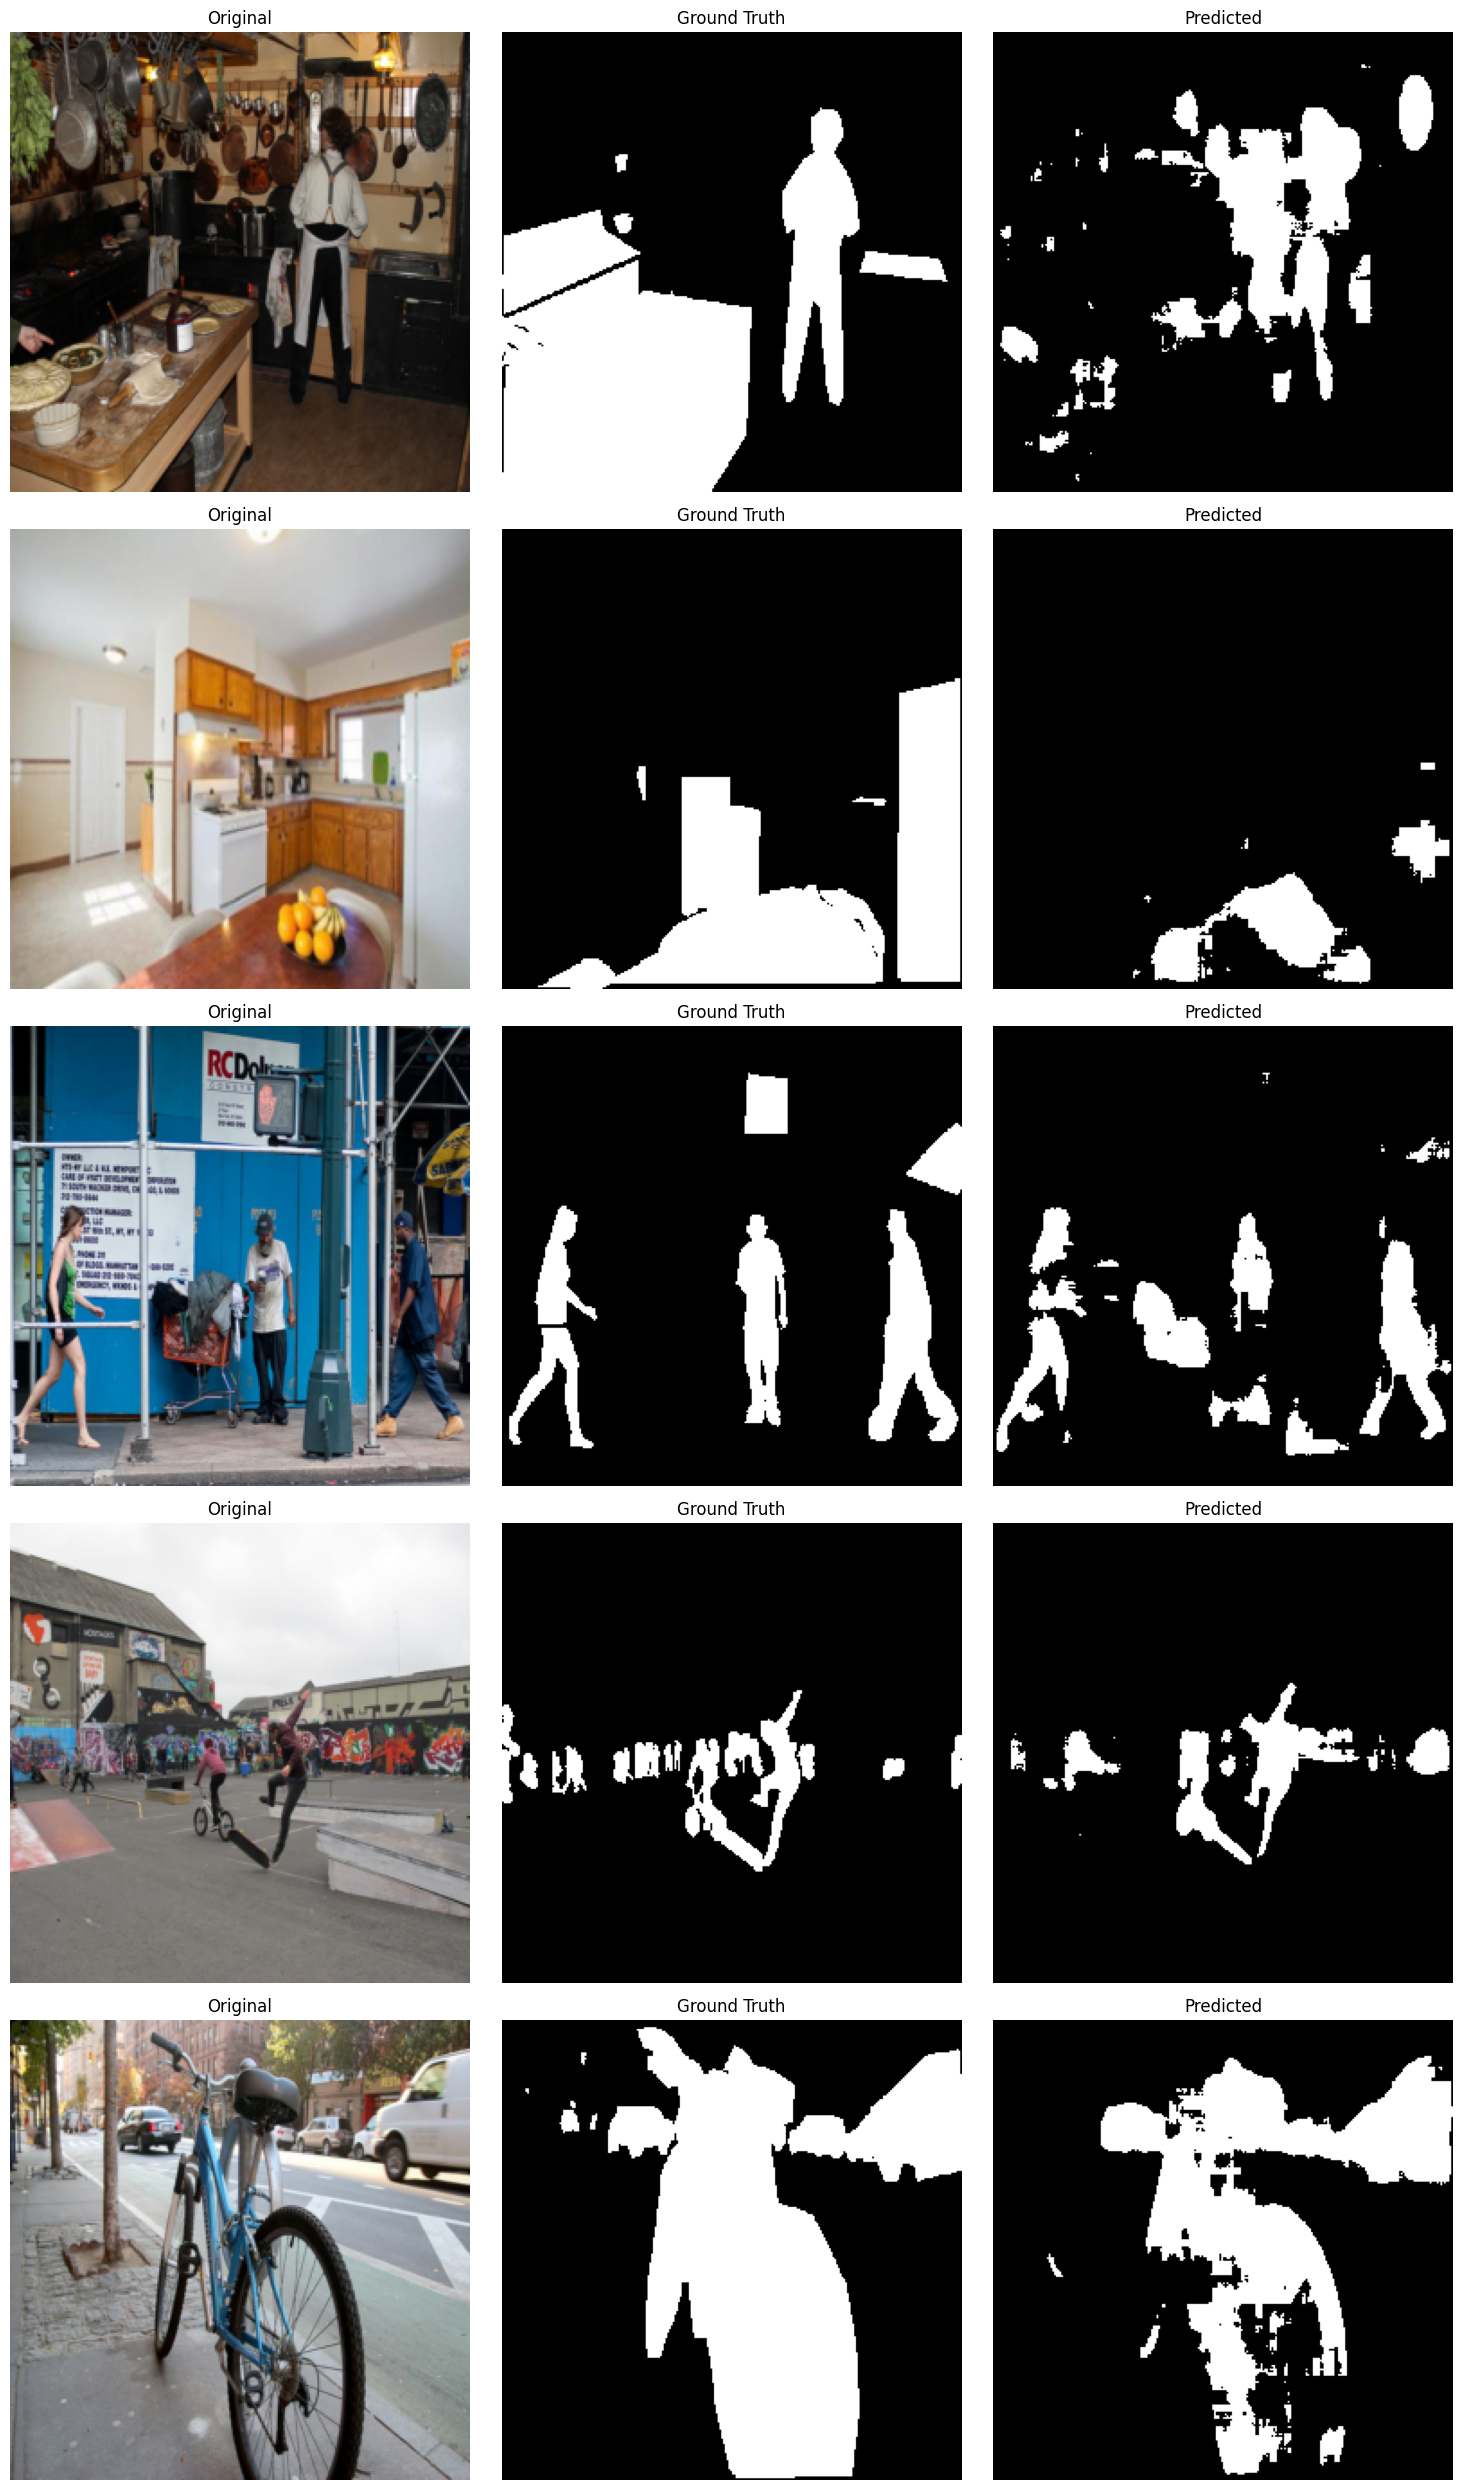


All tasks complete.


In [ ]:
print("SECTION 5: Saving fine-tuned model and visualizing results...")

torch.save(model.state_dict(), FINETUNED_MODEL_SAVE_PATH)
print(f"Fine-tuned model saved to {FINETUNED_MODEL_SAVE_PATH}")

def show_predictions(loader, num_images=5):
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)
    with torch.no_grad(): pred_masks = model(images)
    images, masks, pred_masks = images.cpu(), masks.cpu(), pred_masks.cpu()
    inv_normalize = transforms.Normalize(mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225], std=[1/0.229,1/0.224,1/0.225])
    plt.figure(figsize=(15, 5 * num_images))
    for i in range(min(num_images, len(images))):
        img_to_show = inv_normalize(images[i])
        plt.subplot(num_images, 3, i*3+1); plt.imshow(img_to_show.permute(1,2,0).clamp(0,1)); plt.title("Original"); plt.axis('off')
        plt.subplot(num_images, 3, i*3+2); plt.imshow(masks[i].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
        plt.subplot(num_images, 3, i*3+3); plt.imshow(torch.sigmoid(pred_masks[i]).squeeze()>0.5, cmap='gray'); plt.title("Predicted"); plt.axis('off')
    plt.tight_layout(); plt.show()

show_predictions(val_loader)
print("\nAll tasks complete.")

In [ ]:
!pip install segmentation-models-pytorch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.9 MB/s eta 0:00:00


In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pycocotools.coco import COCO
import numpy as np
import matplotlib.pyplot as plt
import os, zipfile, requests
from io import BytesIO
from tqdm import tqdm
import segmentation_models_pytorch as smp

IMG_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 25
FINETUNE_LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
FINETUNED_MODEL_SAVE_PATH = 'unet-resnet34_finetuned.pth'

DATA_DIR, IMG_DIR = "coco2017", "coco2017/val2017"
ANNOTATION_URL = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
IMAGE_URL = 'http://images.cocodataset.org/zips/val2017.zip'
ANNOTATION_FILE = os.path.join(DATA_DIR, 'annotations/instances_val2017.json')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def download_and_extract(url, extract_to='.'):
    if os.path.exists(extract_to) and len(os.listdir(extract_to)) > 1: return
    print(f"Downloading data from {url}...")
    try:
        with requests.get(url, stream=True) as r, zipfile.ZipFile(BytesIO(r.content)) as z:
            r.raise_for_status(); z.extractall(extract_to)
        print("Download complete.")
    except Exception as e: print(f"Failed to download/extract: {e}")
os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(os.path.join(DATA_DIR, 'annotations')): download_and_extract(ANNOTATION_URL, DATA_DIR)
if not os.path.exists(IMG_DIR): download_and_extract(IMAGE_URL, DATA_DIR)
print("Setup complete.\n")
print("SECTION 2: Preparing data pipeline...")
img_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
mask_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()])

class CocoSegmentationDataset(Dataset):
    def __init__(self, img_dir, annotation_file, img_transform=None, mask_transform=None, augment=False):
        self.img_dir, self.coco = img_dir, COCO(annotation_file)
        self.img_ids = [i for i in self.coco.getImgIds() if len(self.coco.getAnnIds(imgIds=i)) > 0]
        self.img_transform, self.mask_transform, self.augment = img_transform, mask_transform, augment
    def __len__(self): return len(self.img_ids)
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        for ann in anns: mask = np.maximum(mask, self.coco.annToMask(ann))
        mask = Image.fromarray(mask)
        if self.augment:
            if torch.rand(1) < 0.5:
                image = transforms.functional.hflip(image); mask = transforms.functional.hflip(mask)
            if torch.rand(1) < 0.3:
                angle = transforms.RandomRotation.get_params([-15, 15])
                image = transforms.functional.rotate(image, angle); mask = transforms.functional.rotate(mask, angle)
        if self.img_transform: image = self.img_transform(image)
        if self.mask_transform: mask = self.mask_transform(mask)
        return image, (mask > 0).float()

train_dataset = CocoSegmentationDataset(IMG_DIR, ANNOTATION_FILE, img_transforms, mask_transforms, augment=True)
# For simplicity, we'll use the same set for validation, but splitting is recommended for real projects
val_dataset = CocoSegmentationDataset(IMG_DIR, ANNOTATION_FILE, img_transforms, mask_transforms, augment=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Data pipeline ready. Samples: {len(train_dataset)}\n")

print("SECTION 3: Building U-Net model with a pre-trained ResNet34 encoder...")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

print(f"Pre-trained U-Net (ResNet34) model built and moved to {device}.\n")

Using device: cuda
Setup complete.

SECTION 2: Preparing data pipeline...
loading annotations into memory...
Done (t=0.81s)
creating index...
index created!
loading annotations into memory...
Done (t=0.55s)
creating index...
index created!
Data pipeline ready. Samples: 4952

SECTION 3: Building U-Net model with a pre-trained ResNet34 encoder...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Pre-trained U-Net (ResNet34) model built and moved to cuda.



SECTION 4: Starting model fine-tuning...


Fine-Tune Epoch 1/25 [Train]: 100%|██████████| 310/310 [01:22<00:00,  3.77it/s, loss=0.4021]


Epoch 1/25 -> Val Loss: 0.2906, Val Dice: 0.7918, Val Acc: 87.94%


Fine-Tune Epoch 2/25 [Train]: 100%|██████████| 310/310 [01:21<00:00,  3.80it/s, loss=0.3052]


Epoch 2/25 -> Val Loss: 0.2523, Val Dice: 0.8281, Val Acc: 89.61%


...

Epoch 23/25 -> Val Loss: 0.0951, Val Dice: 0.9343, Val Acc: 96.13%


Fine-Tune Epoch 24/25 [Train]: 100%|██████████| 310/310 [01:21<00:00,  3.79it/s, loss=0.1080]


Epoch 24/25 -> Val Loss: 0.0952, Val Dice: 0.9346, Val Acc: 96.18%


Fine-Tune Epoch 25/25 [Train]: 100%|██████████| 310/310 [01:21<00:00,  3.78it/s, loss=0.1059]


Epoch 25/25 -> Val Loss: 0.0960, Val Dice: 0.9342, Val Acc: 96.07%
Fine-tuning finished.

SECTION 5: Saving fine-tuned model and visualizing results...
Fine-tuned model saved to unet-resnet34_finetuned.pth


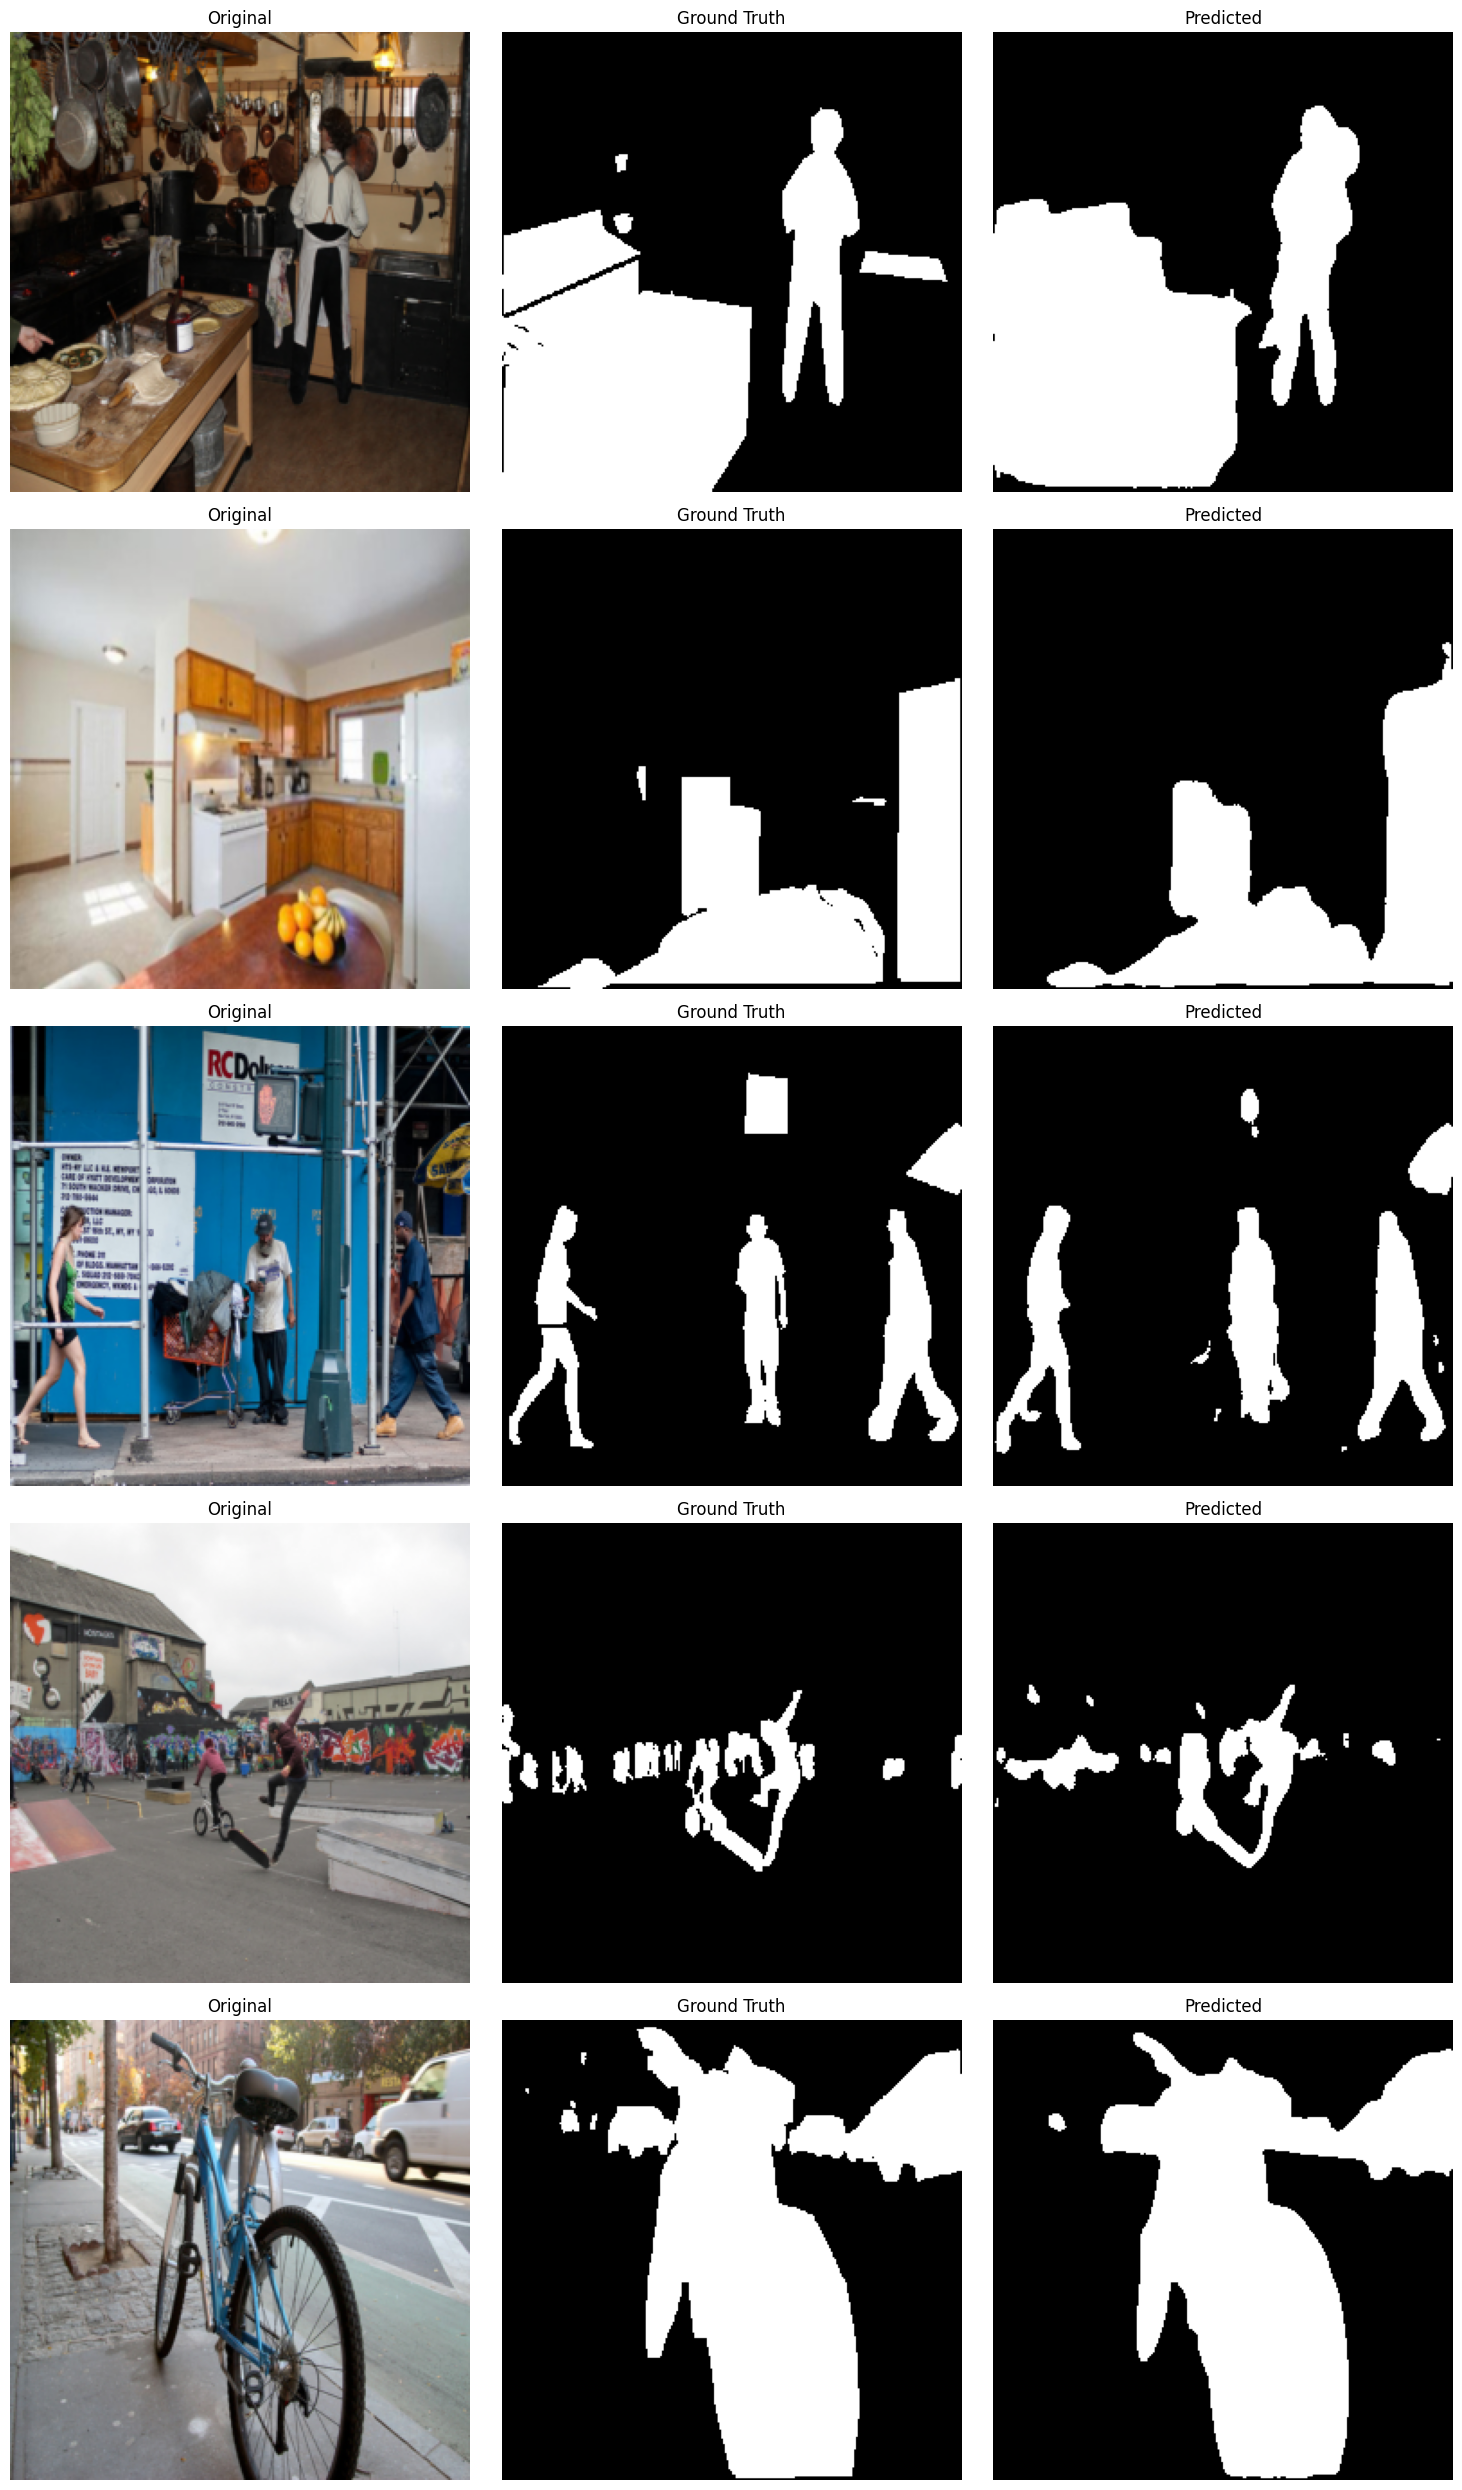


All tasks complete.


In [ ]:
print("SECTION 4: Starting model fine-tuning...")

optimizer = optim.AdamW(model.parameters(), lr=FINETUNE_LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.1)

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6): super().__init__(); self.smooth = smooth
    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        intersection = (preds * targets).sum()
        union = preds.sum() + targets.sum()
        return 1 - ((2. * intersection + self.smooth) / (union + self.smooth))

bce_loss = nn.BCEWithLogitsLoss()
dice_loss = DiceLoss()
def combined_loss(preds, targets, bce_weight=0.7):
    return bce_weight * bce_loss(preds, targets) + (1 - bce_weight) * dice_loss(preds, targets)

def dice_coefficient(preds, targets, smooth=1e-6):
    preds = torch.sigmoid(preds) > 0.5
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum()
    return (2. * intersection + smooth) / (union + smooth)

def pixel_accuracy(preds, targets):
    correct = (torch.sigmoid(preds) > 0.5) == targets
    return correct.float().mean() * 100

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Fine-Tune Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, masks in progress_bar:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images); loss = combined_loss(outputs, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        train_loss += loss.item()
        progress_bar.set_postfix(loss=f'{train_loss/(progress_bar.n+1):.4f}')

    model.eval()
    val_loss, val_dice, val_acc = 0.0, 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            val_loss += combined_loss(outputs, masks).item()
            val_dice += dice_coefficient(outputs, masks).item()
            val_acc += pixel_accuracy(outputs, masks).item()

    avg_val_loss = val_loss/len(val_loader)
    avg_val_dice = val_dice/len(val_loader)
    avg_val_acc = val_acc/len(val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} -> Val Loss: {avg_val_loss:.4f}, Val Dice: {avg_val_dice:.4f}, Val Acc: {avg_val_acc:.2f}%")
    scheduler.step(avg_val_loss)

print("Fine-tuning finished.\n")
print("SECTION 5: Saving fine-tuned model and visualizing results...")

torch.save(model.state_dict(), FINETUNED_MODEL_SAVE_PATH)
print(f"Fine-tuned model saved to {FINETUNED_MODEL_SAVE_PATH}")

def show_predictions(loader, num_images=5):
    model.eval()
    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)
    with torch.no_grad(): pred_masks = model(images)
    images, masks, pred_masks = images.cpu(), masks.cpu(), pred_masks.cpu()
    inv_normalize = transforms.Normalize(mean=[-0.485/0.229,-0.456/0.224,-0.406/0.225], std=[1/0.229,1/0.224,1/0.225])
    plt.figure(figsize=(15, 5 * num_images))
    for i in range(min(num_images, len(images))):
        img_to_show = inv_normalize(images[i])
        plt.subplot(num_images, 3, i*3+1); plt.imshow(img_to_show.permute(1,2,0).clamp(0,1)); plt.title("Original"); plt.axis('off')
        plt.subplot(num_images, 3, i*3+2); plt.imshow(masks[i].squeeze(), cmap='gray'); plt.title("Ground Truth"); plt.axis('off')
        plt.subplot(num_images, 3, i*3+3); plt.imshow(torch.sigmoid(pred_masks[i]).squeeze()>0.5, cmap='gray'); plt.title("Predicted"); plt.axis('off')
    plt.tight_layout(); plt.show()

show_predictions(val_loader)
print("\nAll tasks complete.")